In [1]:
from pathlib import Path

# -----------------------------
# Config
# -----------------------------
ROOT = Path("/home/jovyan")

# Folders to skip (common noisy dirs)
EXCLUDE_DIRS = {
    ".git",
    "__pycache__",
    ".ipynb_checkpoints",
    ".cache",
    ".conda",
    ".mamba",
    ".local",
    ".npm",
    ".yarn",
    ".venv",
    "venv",
    "site-packages",
    ".Trash",
}

# If True, the scan skips any directory whose name is in EXCLUDE_DIRS
SKIP_EXCLUDED_DIRS = True

# Optional: hard cap number of files (safety). Set None for unlimited.
MAX_FILES = None


In [2]:
import os
from collections import defaultdict

def should_skip_dir(path: Path) -> bool:
    if not SKIP_EXCLUDED_DIRS:
        return False
    return any(part in EXCLUDE_DIRS for part in path.parts)

stats = defaultdict(lambda: {"count": 0, "bytes": 0})

scanned_files = 0
skipped_files = 0
errors = 0

for p in ROOT.rglob("*"):
    try:
        if p.is_dir():
            # prune by skipping traversal-like behaviour (rglob still yields, but we can ignore files inside by checking parts)
            continue

        if should_skip_dir(p):
            skipped_files += 1
            continue

        if not p.is_file():
            continue

        # Stop if capped
        if MAX_FILES is not None and scanned_files >= MAX_FILES:
            break

        ext = p.suffix.lower().strip(".")
        ext = ext if ext else "(no_ext)"

        size = p.stat().st_size

        stats[ext]["count"] += 1
        stats[ext]["bytes"] += size

        scanned_files += 1

    except Exception:
        errors += 1

scanned_files, skipped_files, errors


(69847, 210517, 0)

In [3]:
import pandas as pd

df = (
    pd.DataFrame(
        [{"extension": k, "files": v["count"], "bytes": v["bytes"]} for k, v in stats.items()]
    )
    .sort_values(["bytes", "files"], ascending=[False, False])
    .reset_index(drop=True)
)

df["mb"] = df["bytes"] / (1024 * 1024)
df["gb"] = df["bytes"] / (1024 * 1024 * 1024)

df.head(30)


,extension,files,bytes,mb,gb
0,tif,22966,20588025856739,1.963427e+07,19174.093247
1,img,9092,596054184929,5.684416e+05,555.118718
2,ovr,24,5445208640,5.192956e+03,5.071246
3,shp,1344,4419619032,4.214877e+03,4.116091
4,zip,7,684746866,6.530255e+02,0.637720
5,dbf,1344,161303076,1.538306e+02,0.150225
6,139,1,123600896,1.178750e+02,0.115112
7,ipynb,136,83599379,7.972658e+01,0.077858
8,(no_ext),99,56731551,5.410342e+01,0.052835
9,csv,502,54650730,5.211900e+01,0.050897


In [4]:
total_bytes = df["bytes"].sum()
total_files = df["files"].sum()

top = df.head(15).copy()
top["pct_bytes"] = (top["bytes"] / total_bytes) * 100
top["pct_files"] = (top["files"] / total_files) * 100

top[["extension", "files", "mb", "pct_files", "gb", "pct_bytes"]]


,extension,files,mb,pct_files,gb,pct_bytes
0,tif,22966,1.963427e+07,32.880439,19174.093247,97.134872
1,img,9092,5.684416e+05,13.017023,555.118718,2.812200
2,ovr,24,5.192956e+03,0.034361,5.071246,0.025691
3,shp,1344,4.214877e+03,1.924206,4.116091,0.020852
4,zip,7,6.530255e+02,0.010022,0.637720,0.003231
5,dbf,1344,1.538306e+02,1.924206,0.150225,0.000761
6,139,1,1.178750e+02,0.001432,0.115112,0.000583
7,ipynb,136,7.972658e+01,0.194711,0.077858,0.000394
8,(no_ext),99,5.410342e+01,0.141738,0.052835,0.000268
9,csv,502,5.211900e+01,0.718714,0.050897,0.000258


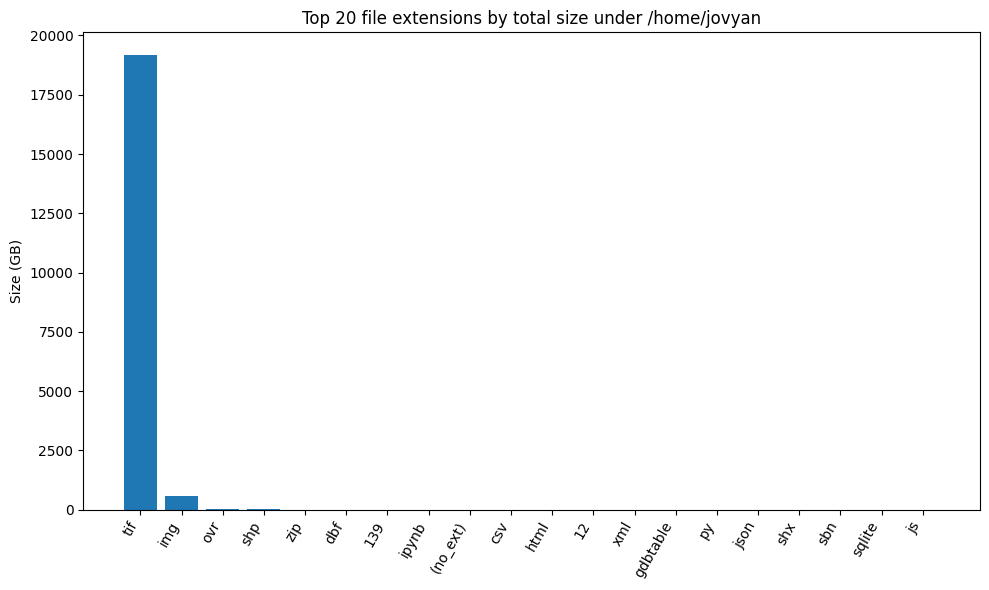

In [5]:
import matplotlib.pyplot as plt

TOP_N = 20
plot_df = df.head(TOP_N)

plt.figure(figsize=(10, 6))
plt.bar(plot_df["extension"], plot_df["gb"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Size (GB)")
plt.title(f"Top {TOP_N} file extensions by total size under {ROOT}")
plt.tight_layout()
plt.show()


In [6]:
from pathlib import Path

ROOT = Path("/home/jovyan")

# Size threshold (GB)
MIN_SIZE_GB = 0.5   # change to 0.1, 1, etc if you want
MIN_SIZE_BYTES = int(MIN_SIZE_GB * 1024**3)

# Skip noisy dirs (same idea as before)
EXCLUDE_DIRS = {
    ".git",
    "__pycache__",
    ".ipynb_checkpoints",
    ".cache",
    ".conda",
    ".mamba",
    ".local",
    ".venv",
    "venv",
    "site-packages",
}


In [7]:
big_tifs = []

def should_skip(path: Path) -> bool:
    return any(part in EXCLUDE_DIRS for part in path.parts)

for p in ROOT.rglob("*"):
    try:
        if not p.is_file():
            continue
        if should_skip(p):
            continue
        if p.suffix.lower() not in (".tif", ".tiff"):
            continue

        size = p.stat().st_size
        if size >= MIN_SIZE_BYTES:
            big_tifs.append({
                "path": str(p),
                "gb": size / 1024**3,
                "mb": size / 1024**2,
            })
    except Exception:
        pass

len(big_tifs)


18330

In [8]:
import pandas as pd

df = pd.DataFrame(big_tifs)

if df.empty:
    print("No GeoTIFFs above threshold.")
else:
    df = df.sort_values("gb", ascending=False).reset_index(drop=True)
    df


In [9]:
for _, r in df.iterrows():
    print(f"{r['gb']:.2f} GB  {r['path']}")


1.71 GB  /home/jovyan/scratch/eds/tiles/p104r070/sr/2025/202506/ls89sr_p104r070_20250601_nbart6m.tif
1.71 GB  /home/jovyan/scratch/eds/tiles/p104r070/sr/2025/202507/ls89sr_p104r070_20250727_nbart6m.tif
1.71 GB  /home/jovyan/scratch/eds/tiles/p104r070/sr/2025/202508/ls89sr_p104r070_20250820_nbart6m.tif
1.71 GB  /home/jovyan/scratch/eds/tiles/p104r070/sr/2025/202508/ls89sr_p104r070_20250804_nbart6m.tif
1.71 GB  /home/jovyan/scratch/eds/tiles/p104r070/sr/2025/202505/ls89sr_p104r070_20250524_nbart6m.tif
1.71 GB  /home/jovyan/scratch/eds/tiles/p104r070/sr/2025/202505/ls89sr_p104r070_20250508_nbart6m.tif
1.71 GB  /home/jovyan/scratch/eds/tiles/p104r070/sr/2025/202506/ls89sr_p104r070_20250609_nbart6m.tif
1.71 GB  /home/jovyan/scratch/eds/tiles/p104r070/sr/2025/202506/ls89sr_p104r070_20250625_nbart6m.tif
1.71 GB  /home/jovyan/scratch/eds/tiles/p104r070/sr/2025/202506/ls89sr_p104r070_20250617_nbart6m.tif
1.71 GB  /home/jovyan/scratch/eds/tiles/p104r070/sr/2025/202508/ls89sr_p104r070_20250812_nb